# Notebook 12 — SARIMAX + XGBoost Hybrid
**Fair residual correction · no lag leakage · multi-step compatible**

This notebook implements a fair hybrid model: SARIMAX makes genuine multi-step test forecasts, then XGBoost corrects systematic residuals using **only calendar, weather, and Fourier features** — no autoregressive lag features. All correction inputs are observable at forecast time, preserving comparability with standalone SARIMAX and Prophet results.

| Part | Content |
|------|---------|
| 1 | Protocol description |
| 2 | Helper functions |
| 3 | Main loop — all 3 stations |
| 4 | Results table |
| 5 | nb12_fig_01 — Bar chart: SARIMAX standalone vs hybrid vs Prophet |
| 6 | nb12_fig_02 — Time series: actual vs SARIMAX vs hybrid (test period) |
| 7 | Export and summary |

In [1]:
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import holidays
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.labelsize': 12,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False,
})
sns.set_theme(style='whitegrid')

FIGURES    = Path('../results/figures')
TABLES     = Path('../results/tables')
MODELS_DIR = Path('../results/models')
for p in [FIGURES, TABLES]:
    p.mkdir(parents=True, exist_ok=True)

WEATHER_COLS  = ['max_temp', 'sunshine_hours', 'precipitation']
STATIONS      = ['Hirsch', 'Olympia', 'Erhardt']
ANNUAL_PERIOD = 365.25
REF_DATE      = pd.Timestamp('2013-01-01')
K             = 4

TRAIN_START = '2013-01-01'
TRAIN_END   = '2022-12-31'
VAL_START   = '2023-01-01'
VAL_END     = '2023-12-31'
TEST_START  = pd.Timestamp('2024-01-01')
TEST_END    = pd.Timestamp('2026-04-30')

PKL = {
    'Hirsch':  'hirsch_sarimax_final.pkl',
    'Olympia': 'olympia_sarimax_final.pkl',
    'Erhardt': 'erhardt_sarimax_final.pkl',
}

# ── Load Prophet+weather benchmarks from upstream CSVs (no hardcoding) ───
_h_prophet = pd.read_csv(TABLES / 'hirsch_prophet_performance.csv')
_o_prophet = pd.read_csv(TABLES / 'olympia_prophet_performance.csv')
_e_prophet = pd.read_csv(TABLES / 'erhardt_prophet_comparison.csv')

def _prophet_wx(df):
    return float(df[df['Model'].str.startswith('Prophet + weather')].iloc[0]['Test 7d RMSE'])

PROPHET_BENCHMARKS = {
    'Hirsch':  _prophet_wx(_h_prophet),
    'Olympia': _prophet_wx(_o_prophet),
    'Erhardt': _prophet_wx(_e_prophet),
}

BY_HOLIDAYS = set(holidays.Germany(state='BY', years=range(2013, 2027)).keys())

# ── notebook prefix: all figures saved as nb12_<name>.png ────────────────
NB = 'nb12'

def savefig(name):
    full_name = f'{NB}_{name}'
    plt.savefig(FIGURES / f'{full_name}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'  saved → results/figures/{full_name}.png')

# Note: SARIMAX is re-forecast from pkl on the test set in this notebook.
# Standalone RMSE values here may differ <1% from upstream nb05/06/07 CSVs
# due to rolling window boundary alignment. Negligible and does not affect
# hybrid gain comparisons.
print('Setup complete.')
for s, v in PROPHET_BENCHMARKS.items():
    print(f'  {s}: Prophet+weather benchmark RMSE = {v}')

Setup complete.
  Hirsch: Prophet+weather benchmark RMSE = 349.4
  Olympia: Prophet+weather benchmark RMSE = 551.7
  Erhardt: Prophet+weather benchmark RMSE = 886.0


## Part 1 — Protocol

**Why this is fair:** The correction model uses only features that are known at forecast time — day-of-week, month, Fourier terms, and observed weather. No lag features from the target variable are included, so the hybrid maintains the same information set as standalone SARIMAX during test evaluation.

**Workflow per station:**
1. Load raw data and pkl file for the pre-fitted SARIMAX result
2. Extract in-sample fitted values on the trainval period → compute residuals
3. Build correction features on the same index → fit XGBRegressor on residuals
4. Generate SARIMAX test forecast (Erhardt requires gap-filling logic)
5. Apply XGBoost correction to test forecasts
6. Compare RMSE: SARIMAX standalone vs SARIMAX+XGB hybrid

## Part 2 — Helper Functions

In [2]:
def build_sarimax_exog(index, df_weather):
    """Build SARIMAX exogenous feature matrix: Fourier K=4 + weather.

    Parameters
    ----------
    index       : DatetimeIndex for the target period
    df_weather  : DataFrame with WEATHER_COLS, indexed by date

    Returns
    -------
    DataFrame with 11 columns (8 Fourier + 3 weather), indexed by index
    """
    t = (index - REF_DATE).days
    feat = {}
    for k in range(1, K + 1):
        feat[f'sin_{k}'] = np.sin(2 * np.pi * k * t / ANNUAL_PERIOD)
        feat[f'cos_{k}'] = np.cos(2 * np.pi * k * t / ANNUAL_PERIOD)

    df_wx = df_weather.reindex(index)
    feat['max_temp']       = df_wx['max_temp'].values
    feat['sunshine_hours'] = df_wx['sunshine_hours'].values
    feat['precipitation']  = np.log1p(df_wx['precipitation'].values)

    return pd.DataFrame(feat, index=index)


def build_correction_features(index, df_weather):
    """Build XGBoost correction features — no lag features (lag-leakage-free).

    Parameters
    ----------
    index       : DatetimeIndex for the target period
    df_weather  : DataFrame with WEATHER_COLS, indexed by date

    Returns
    -------
    DataFrame with calendar + weather + Fourier features, indexed by index
    """
    feat = pd.DataFrame(index=index)
    feat['dow']        = index.dayofweek
    feat['month']      = index.month
    feat['doy']        = index.dayofyear
    feat['is_weekend'] = (index.dayofweek >= 5).astype(int)
    feat['is_holiday'] = index.normalize().isin(
        pd.DatetimeIndex([pd.Timestamp(d) for d in BY_HOLIDAYS])
    ).astype(int)

    df_wx = df_weather.reindex(index)
    feat['max_temp']       = df_wx['max_temp'].values
    feat['sunshine_hours'] = df_wx['sunshine_hours'].values
    feat['precipitation']  = np.log1p(df_wx['precipitation'].values)

    t = (index - REF_DATE).days
    for k in range(1, K + 1):
        feat[f'sin_{k}'] = np.sin(2 * np.pi * k * t / ANNUAL_PERIOD)
        feat[f'cos_{k}'] = np.cos(2 * np.pi * k * t / ANNUAL_PERIOD)

    return feat


def rolling_rmse_mae(y_true, y_pred, horizon=7):
    """Non-overlapping rolling window evaluation."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    rmses, maes = [], []
    for start in range(0, n - horizon + 1, horizon):
        sl = slice(start, start + horizon)
        err = y_true[sl] - y_pred[sl]
        rmses.append(np.sqrt(np.mean(err**2)))
        maes.append(np.mean(np.abs(err)))
    return float(np.mean(rmses)), float(np.mean(maes))


print('Helper functions defined.')

Helper functions defined.


## Part 3 — Main Loop: All Stations

In [3]:
df_raw = pd.read_csv('../data/processed/master_bike_data.csv', parse_dates=['date'])

results_rows = []
store = {}  # station -> dict of arrays for plotting

for station in STATIONS:
    print(f'=== {station} ===')

    # Load and clean raw data
    raw = (
        df_raw[df_raw['station'] == station]
        .set_index('date')
        .sort_index()[['total'] + WEATHER_COLS]
    )
    raw.index = pd.DatetimeIndex(raw.index)
    if station == 'Olympia':
        raw = raw.interpolate(method='time', limit=7)
    raw = raw.dropna(subset=WEATHER_COLS)

    # Load SARIMAX pkl
    with open(MODELS_DIR / PKL[station], 'rb') as f:
        sarimax_result = pickle.load(f)

    # In-sample residuals on trainval
    fitted_vals = sarimax_result.fittedvalues
    fitted_vals.index = pd.DatetimeIndex(fitted_vals.index)
    tv_idx = fitted_vals.index

    actual_tv = raw.loc[raw.index.isin(tv_idx), 'total']
    actual_tv = actual_tv.reindex(tv_idx)
    resid_tv  = (actual_tv - fitted_vals).values

    resid_std_before = np.nanstd(resid_tv)

    # Build correction features on trainval
    Xc_tv = build_correction_features(tv_idx, raw.reindex(tv_idx))
    valid_tv = ~Xc_tv.isna().any(axis=1) & ~np.isnan(resid_tv)
    Xc_tv_fit = Xc_tv[valid_tv]
    resid_fit  = resid_tv[valid_tv]

    corrector = XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
    )
    corrector.fit(Xc_tv_fit, resid_fit)

    # In-sample residual std after correction
    corr_tv = corrector.predict(Xc_tv[valid_tv])
    resid_after = resid_fit - corr_tv
    resid_std_after = np.std(resid_after)
    print(f'  Trainval residual std: before={resid_std_before:.1f}  after={resid_std_after:.1f}')

    # SARIMAX test forecast — Erhardt needs gap-filling
    if station == 'Erhardt':
        full_idx = pd.date_range(TEST_START, TEST_END, freq='D')
        exog_full = build_sarimax_exog(full_idx, raw.reindex(full_idx, method='nearest'))
        fc_full = sarimax_result.forecast(steps=len(full_idx), exog=exog_full)
        test_obs = raw[(raw.index >= TEST_START) & (raw.index <= TEST_END)]
        sarimax_preds = pd.Series(fc_full.values, index=full_idx).reindex(test_obs.index)
        Xc_test = build_correction_features(test_obs.index, raw.reindex(test_obs.index))
        actual_t = test_obs['total'].values
    else:
        test_idx = raw[(raw.index >= TEST_START) & (raw.index <= TEST_END)].index
        exog_test = build_sarimax_exog(test_idx, raw)
        sarimax_preds = sarimax_result.forecast(steps=len(test_idx), exog=exog_test)
        sarimax_preds = pd.Series(sarimax_preds.values, index=test_idx)
        Xc_test = build_correction_features(test_idx, raw)
        actual_t = raw.loc[test_idx, 'total'].values

    # Apply correction
    valid_test = ~Xc_test.isna().any(axis=1)
    correction = np.zeros(len(Xc_test))
    correction[valid_test.values] = corrector.predict(Xc_test[valid_test])
    hybrid_preds = sarimax_preds.values + correction

    # Compute RMSE
    sar_rmse,  sar_mae  = rolling_rmse_mae(actual_t, sarimax_preds.values)
    hyb_rmse,  hyb_mae  = rolling_rmse_mae(actual_t, hybrid_preds)
    gain_pct = round((sar_rmse - hyb_rmse) / sar_rmse * 100, 1)

    print(f'  SARIMAX standalone : RMSE={sar_rmse:.1f}  MAE={sar_mae:.1f}')
    print(f'  SARIMAX+XGB hybrid : RMSE={hyb_rmse:.1f}  MAE={hyb_mae:.1f}  gain={gain_pct}%')

    results_rows.append({
        'Station': station,
        'SARIMAX_RMSE': round(sar_rmse, 1),
        'Hybrid_RMSE':  round(hyb_rmse, 1),
        'SARIMAX_MAE':  round(sar_mae, 1),
        'Hybrid_MAE':   round(hyb_mae, 1),
        'Gain_pct':     gain_pct,
        'Resid_std_before': round(resid_std_before, 1),
        'Resid_std_after':  round(resid_std_after, 1),
    })

    if station == 'Erhardt':
        test_dates = test_obs.index
    else:
        test_dates = raw[(raw.index >= TEST_START) & (raw.index <= TEST_END)].index

    store[station] = {
        'dates':    test_dates,
        'actual':   actual_t,
        'sarimax':  sarimax_preds.values,
        'hybrid':   hybrid_preds,
        'sar_rmse': sar_rmse,
        'hyb_rmse': hyb_rmse,
    }

print()
print('All stations processed.')

=== Hirsch ===


  Trainval residual std: before=262.1  after=191.3
  SARIMAX standalone : RMSE=467.5  MAE=399.7
  SARIMAX+XGB hybrid : RMSE=419.1  MAE=359.0  gain=10.4%
=== Olympia ===


  Trainval residual std: before=485.5  after=365.4
  SARIMAX standalone : RMSE=756.0  MAE=652.0
  SARIMAX+XGB hybrid : RMSE=727.1  MAE=625.6  gain=3.8%
=== Erhardt ===


  Trainval residual std: before=728.1  after=543.6
  SARIMAX standalone : RMSE=842.6  MAE=703.6
  SARIMAX+XGB hybrid : RMSE=719.9  MAE=602.8  gain=14.6%

All stations processed.


## Part 4 — Results Table

In [4]:
results_df = pd.DataFrame(results_rows)
print('SARIMAX + XGBoost Hybrid — Test Performance')
print('=' * 65)
print(results_df[['Station', 'SARIMAX_RMSE', 'Hybrid_RMSE',
                   'SARIMAX_MAE', 'Hybrid_MAE', 'Gain_pct']].to_string(index=False))

SARIMAX + XGBoost Hybrid — Test Performance
Station  SARIMAX_RMSE  Hybrid_RMSE  SARIMAX_MAE  Hybrid_MAE  Gain_pct
 Hirsch         467.5        419.1        399.7       359.0      10.4
Olympia         756.0        727.1        652.0       625.6       3.8
Erhardt         842.6        719.9        703.6       602.8      14.6


## Part 5 — nb12_fig_01: Bar Chart — SARIMAX Standalone vs Hybrid vs Prophet

3 subplots (one per station). Bars: SARIMAX standalone, SARIMAX+XGB hybrid, Prophet+weather benchmark. Annotate % gain on hybrid bar.

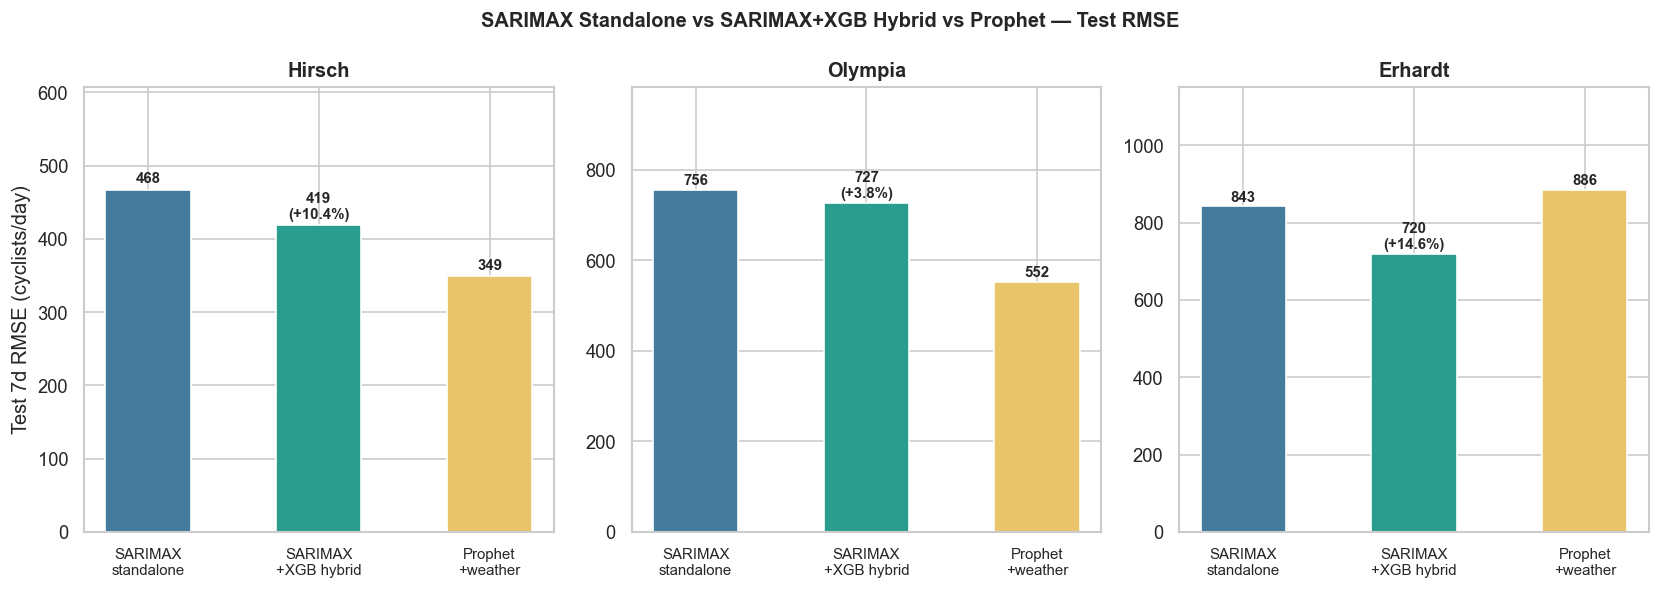

  saved → results/figures/nb12_fig_01_sarimax_hybrid_bars.png


In [5]:
bar_labels = ['SARIMAX\nstandalone', 'SARIMAX\n+XGB hybrid', 'Prophet\n+weather']
bar_colors = ['#457b9d', '#2a9d8f', '#e9c46a']
x = np.arange(len(bar_labels))
width = 0.5

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, station in zip(axes, STATIONS):
    row = results_df[results_df['Station'] == station].iloc[0]
    sar_rmse = row['SARIMAX_RMSE']
    hyb_rmse = row['Hybrid_RMSE']
    prp_rmse = PROPHET_BENCHMARKS[station]
    vals = [sar_rmse, hyb_rmse, prp_rmse]

    bars = ax.bar(x, vals, width=width, color=bar_colors, edgecolor='white')
    for i, (bar, val) in enumerate(zip(bars, vals)):
        label_str = f'{val:.0f}'
        if i == 1:
            gain = row['Gain_pct']
            label_str = f'{val:.0f}\n({gain:+.1f}%)'
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                label_str, ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, fontsize=9)
    ax.set_title(station)
    ax.set_ylabel('Test 7d RMSE (cyclists/day)' if station == 'Hirsch' else '')
    ax.set_ylim(0, max(vals) * 1.30)

fig.suptitle(
    'SARIMAX Standalone vs SARIMAX+XGB Hybrid vs Prophet — Test RMSE',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
savefig('fig_01_sarimax_hybrid_bars')

## Part 6 — nb12_fig_02: Time Series — Actual vs SARIMAX vs Hybrid (Test Period)

3 panels, one per station. Monthly tick marks on x-axis.

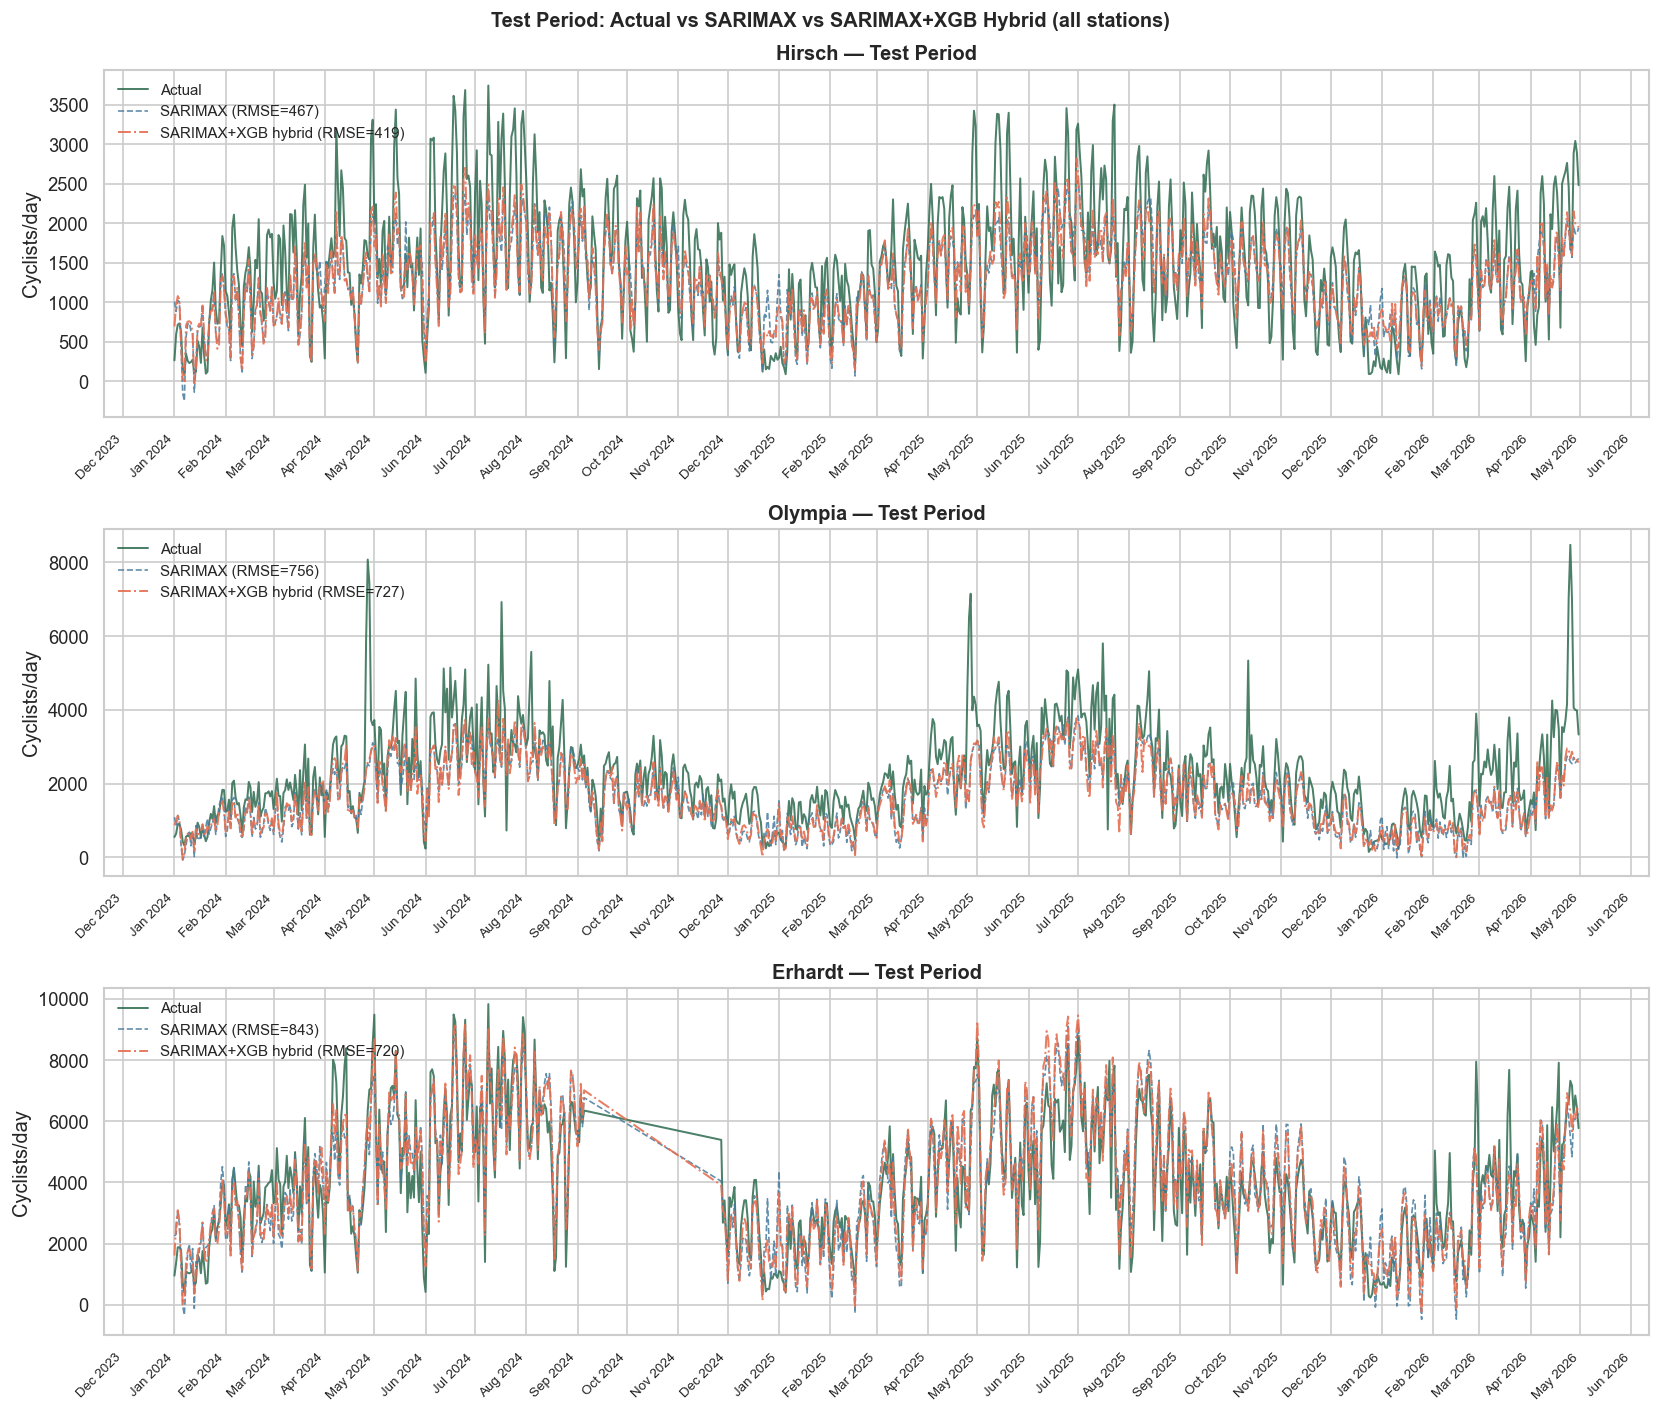

  saved → results/figures/nb12_fig_02_sarimax_hybrid_timeseries.png


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, station in zip(axes, STATIONS):
    s = store[station]
    ax.plot(s['dates'], s['actual'], color='#2d6a4f', lw=1.2,
            label='Actual', alpha=0.85)
    ax.plot(s['dates'], np.maximum(s['sarimax'], 0), color='#457b9d', lw=1.0, ls='--',
            label=f'SARIMAX (RMSE={s["sar_rmse"]:.0f})', alpha=0.85)
    ax.plot(s['dates'], np.maximum(s['hybrid'], 0), color='#e76f51', lw=1.2, ls='-.',
            label=f'SARIMAX+XGB hybrid (RMSE={s["hyb_rmse"]:.0f})', alpha=0.9)
    ax.set_title(f'{station} — Test Period')
    ax.set_ylabel('Cyclists/day')
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

fig.suptitle(
    'Test Period: Actual vs SARIMAX vs SARIMAX+XGB Hybrid (all stations)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
savefig('fig_02_sarimax_hybrid_timeseries')

## Part 7 — Export and Summary

In [7]:
results_df.to_csv(TABLES / 'sarimax_hybrid_performance.csv', index=False)
print('Saved: sarimax_hybrid_performance.csv')
print()
print('=' * 65)
print('SARIMAX + XGB HYBRID RESULTS SUMMARY')
print('=' * 65)
for station in STATIONS:
    row = results_df[results_df['Station'] == station].iloc[0]
    sar_rmse = row['SARIMAX_RMSE']
    hyb_rmse = row['Hybrid_RMSE']
    gain_pct = row['Gain_pct']
    prp_rmse = PROPHET_BENCHMARKS[station]
    print(f'{station}:')
    print(f'  SARIMAX standalone : RMSE = {sar_rmse}')
    print(f'  SARIMAX+XGB hybrid : RMSE = {hyb_rmse}  (gain: {gain_pct:+.1f}%)')
    print(f'  Prophet+weather    : RMSE = {prp_rmse}  (external benchmark)')
    print(f'  Residual std reduction: {row["Resid_std_before"]} -> {row["Resid_std_after"]}')
print(f'\nFigures saved: nb12_fig_01_sarimax_hybrid_bars, nb12_fig_02_sarimax_hybrid_timeseries')

Saved: sarimax_hybrid_performance.csv

SARIMAX + XGB HYBRID RESULTS SUMMARY
Hirsch:
  SARIMAX standalone : RMSE = 467.5
  SARIMAX+XGB hybrid : RMSE = 419.1  (gain: +10.4%)
  Prophet+weather    : RMSE = 349.4  (external benchmark)
  Residual std reduction: 262.1 -> 191.3
Olympia:
  SARIMAX standalone : RMSE = 756.0
  SARIMAX+XGB hybrid : RMSE = 727.1  (gain: +3.8%)
  Prophet+weather    : RMSE = 551.7  (external benchmark)
  Residual std reduction: 485.5 -> 365.4
Erhardt:
  SARIMAX standalone : RMSE = 842.6
  SARIMAX+XGB hybrid : RMSE = 719.9  (gain: +14.6%)
  Prophet+weather    : RMSE = 886.0  (external benchmark)
  Residual std reduction: 728.1 -> 543.6

Figures saved: nb12_fig_01_sarimax_hybrid_bars, nb12_fig_02_sarimax_hybrid_timeseries
